# POC 2 - Finalize chirplet constraint scheme

- Constraints already settled:
    - Absolute BW (200, 2000 Hz)
    - Absolute freq range (50, 7000)
    - Degree (0.5, 3)
    - Duration (10ms, 100ms)
    - *ranges inclusive*
-  Purpose of this notebook: bring in a ratio-based constraint to prevent stagnant instantaneous freq
    - e.g.: fHi / fLo >= RATIO (1.25, 1.5, etc)

In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid as cti
from util import pchirp

%matplotlib widget

In [2]:
# Constants

MIN_RATIO = 1.414
MAX_BW = 2000
MIN_BW = 200

MAX_FREQ = 7000
MIN_FREQ = 50

MAX_DUR_MS = 100
MIN_DUR_MS = 10

MAX_DEGREE = 3
MIN_DEGREE = 0.5

In [3]:
# Helper functions

def get_bw(f1, f2):
    return np.abs(f2 - f1)

def get_fc(f1, f2):
    return (f1 + f2) / 2.

def get_fLo(bw, fc):
    return fc - bw / 2.

def get_fHi(bw, fc):
    return fc + bw / 2.

def get_ratio(f1, f2):
    fHi = max(f1, f2)
    fLo = min(f1, f2)
    return fHi / fLo

def pick_val(lower_bnd, upper_bnd):
    return np.random.uniform(lower_bnd, upper_bnd)

def pick_bw_fc():
    """
    Selects bw and fc that automatically respect imposed constraints
    """
    # Define viable bw selection range based on constraints
    bw_lo = max(MIN_BW, (MIN_FREQ * (MIN_RATIO - 1)))
    bw_hi = min(MAX_BW, (MAX_FREQ - MIN_FREQ))

    # Select bw
    bw = pick_val(bw_lo, bw_hi)
    
    # Define viable fc selection range
    fc_lo = MIN_FREQ + bw / 2
    fc_hi = min((MAX_FREQ - bw / 2), (bw / 2 * (MIN_RATIO + 1) / (MIN_RATIO - 1)))

    # Select fc
    fc_log = pick_val(np.log(fc_lo), np.log(fc_hi))
    fc = np.exp(fc_log)
    
    return bw, fc

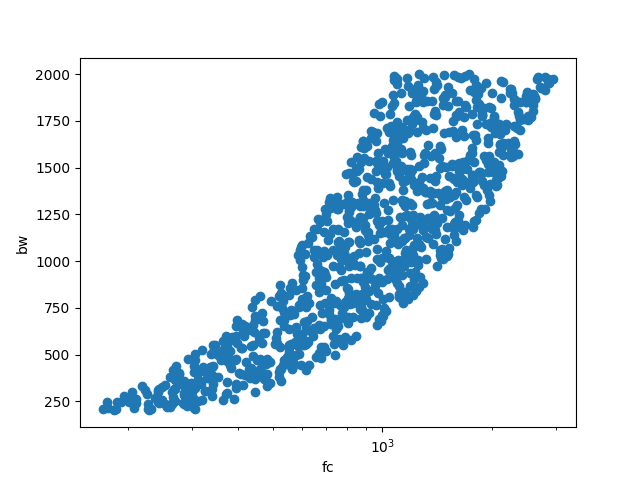

In [4]:
# Run a sweep 
N = 1000
fc_all = np.zeros(N)
bw_all = np.zeros(N)

for i in range(N):
    bw_all[i], fc_all[i] = pick_bw_fc()

plt.figure()
plt.scatter(fc_all, bw_all)
plt.xlabel('fc')
plt.ylabel('bw')
plt.xscale('log')
plt.show()

## Findings

- Constraints can be baked into bw and fc selection directly
- We can ensure X octaves of freq modulation by setting MIN_RATIO = 2 ** X
    - 1/2 octave -> MIN_RATIO = 1.414